# <b>Clusterizacion K-Means</b>

## Carga de datos

In [15]:
import pandas as pd
datos = pd.read_csv("housing.csv")

In [16]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Visualizacion inicial
Relación entre ubicación y valor de vivienda

<Axes: xlabel='latitude', ylabel='longitude'>

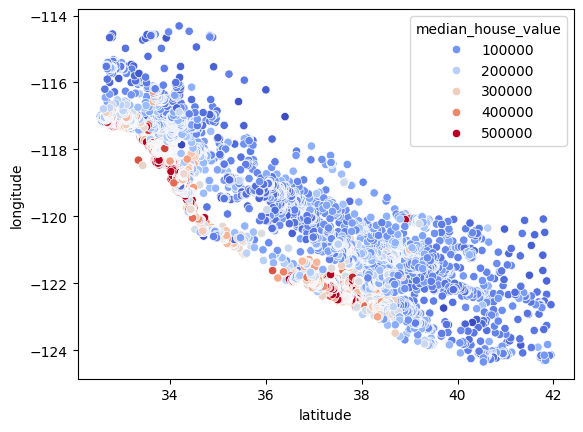

In [17]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="coolwarm")

Relación entre ubicación e ingreso medio

<Axes: xlabel='latitude', ylabel='longitude'>

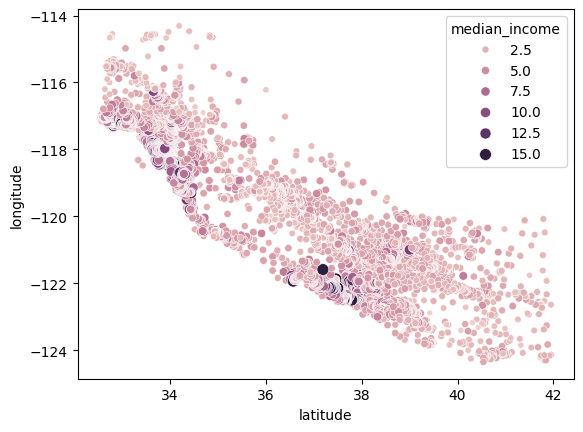

In [18]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_income", size="median_income")

## Selección de variables relevantes

In [19]:
datos.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


## Aplicación de K-Means

In [20]:
from sklearn.cluster import KMeans

x = datos.loc[:, ["latitude", "longitude", "median_income"]]
modelo = KMeans(n_clusters=6)
predicciones = modelo.fit_predict(x)


In [21]:
predicciones.shape

(20640,)

## Creación de segmentos

In [22]:
x["segmento_economico"] = predicciones

In [23]:
x

,latitude,longitude,median_income,segmento_economico
0,37.88,-122.23,8.3252,2
1,37.86,-122.22,8.3014,2
2,37.85,-122.24,7.2574,2
3,37.85,-122.25,5.6431,2
4,37.85,-122.25,3.8462,0
...,...,...,...,...
20635,39.48,-121.09,1.5603,0
20636,39.49,-121.21,2.5568,0
20637,39.43,-121.22,1.7000,0
20638,39.43,-121.32,1.8672,0


## Análisis de segmentos
Conteo de datos por segmento

In [24]:
x["segmento_economico"].value_counts()

,count
segmento_economico,
1,6560
0,4883
3,4205
2,2764
4,1677
5,551


Visualización de clusters

<Axes: xlabel='latitude', ylabel='longitude'>

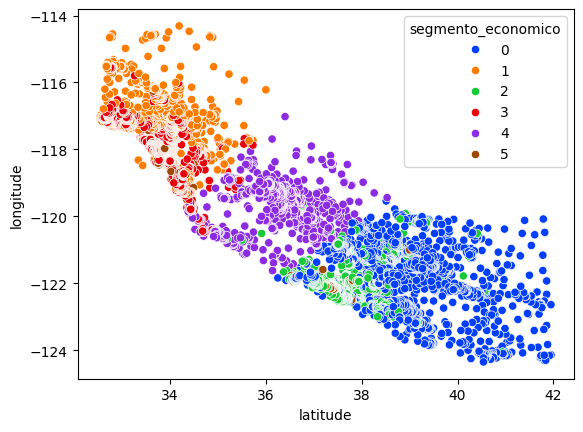

In [26]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=x, hue="segmento_economico", palette="bright")

Distribución de segmentos

<Axes: xlabel='segmento_economico', ylabel='count'>

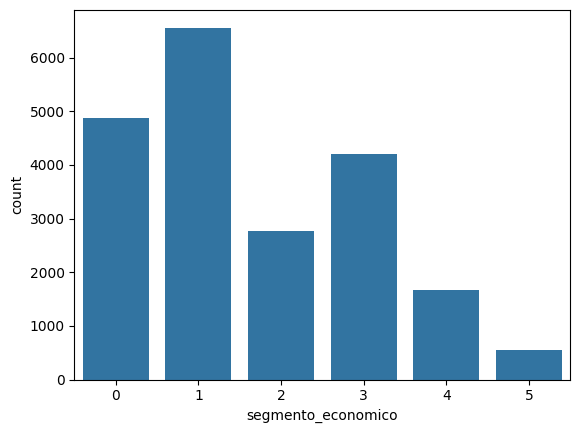

In [28]:
sb.countplot(x="segmento_economico", data=x)

## Promedio de ingreso por segmento

In [29]:
x.groupby(["segmento_economico"])["median_income"].mean()

,median_income
segmento_economico,
0,2.824459
1,2.787924
2,5.524420
3,5.303059
4,2.660862
5,10.488034
